# 03 - Robustness Experiments

## Reliable Machine-Failure Prediction Under Imbalanced and Corrupted Sensor Data

The clean-data baseline experiments showed that an unweighted Random Forest
with a decision threshold of 0.20 provided the strongest failure-detection
performance.

This notebook investigates whether that prediction system remains reliable
when realistic data-quality and data-availability problems are introduced.

The following robustness conditions are studied:

1. Sensor measurement noise
2. Missing sensor measurements
3. Limited training data

Performance under each condition will be compared with the clean-data
reference results.

### Clean-data reference

- Accuracy: 97.27%
- Precision: 56.76%
- Recall: 82.35%
- F1-score: 67.20%
- Average Precision: 78.03%

In [3]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    confusion_matrix
)

RANDOM_STATE = 42

project_root = Path.cwd().parent

print("Project root:", project_root)

Project root: c:\Users\aacaa\Documents\reliable-machine-failure-prediction


In [4]:
src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("Source path:", src_path)

Source path: c:\Users\aacaa\Documents\reliable-machine-failure-prediction\src


In [5]:
from data_loader import (
    load_ai4i_data,
    create_model_data
)

from preprocessing import create_preprocessor

print("Project functions imported successfully.")

Project functions imported successfully.


In [6]:
data = load_ai4i_data()

print("Dataset shape:", data.shape)

display(data.head())

Dataset shape: (10000, 12)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
X, y = create_model_data(data)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(list(X.columns))

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (10000, 6)
Target shape: (10000,)

Features:
['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split

# First split: 70% training and 30% temporary data
X_train, X_temporary, y_train, y_temporary = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide temporary data equally
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temporary,
    y_temporary,
    test_size=0.50,
    random_state=42,
    stratify=y_temporary
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

print("\nFailure counts:")
print("Training:", y_train.sum())
print("Validation:", y_validation.sum())
print("Test:", y_test.sum())


Training shape: (7000, 6)
Validation shape: (1500, 6)
Test shape: (1500, 6)

Failure counts:
Training: 237
Validation: 51
Test: 51


## 2. Recreate the Random Forest Preprocessing

The selected Random Forest model must receive data in the same form used
during the baseline experiments.

For the tree-based model, numerical sensor values are kept on their original
scale, while categorical information is encoded numerically.

The preprocessing pipeline is fitted only on the training data and then
applied unchanged to the validation and test sets.

This prevents data leakage and ensures that the robustness experiments use
the same preprocessing procedure as the original baseline model.

In [12]:
tree_preprocessor = create_preprocessor(
    scale_numeric=False
)

print(tree_preprocessor)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['Air temperature', 'Process temperature',
                                  'Rotational speed', 'Torque', 'Tool wear']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Type'])])


In [13]:
X_train_tree = tree_preprocessor.fit_transform(
    X_train
)

X_validation_tree = tree_preprocessor.transform(
    X_validation
)

X_test_tree = tree_preprocessor.transform(
    X_test
)

print("Training transformed shape:", X_train_tree.shape)
print("Validation transformed shape:", X_validation_tree.shape)
print("Test transformed shape:", X_test_tree.shape)

Training transformed shape: (7000, 8)
Validation transformed shape: (1500, 8)
Test transformed shape: (1500, 8)


## 3. Recreate the Selected Random Forest

The baseline experiments identified the unweighted Random Forest as the
selected model for machine-failure prediction.

The same model configuration is recreated here so that the robustness
experiments use the exact same prediction system as the clean-data baseline.

The model is trained only on the training data. Its configuration is kept
fixed throughout the robustness experiments so that later performance
changes can be attributed to data corruption rather than changes in the model.

In [14]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_tree,
    y_train
)

print("Selected Random Forest trained successfully.")

Selected Random Forest trained successfully.


## 4. Use the Selected Decision Threshold

The Random Forest outputs a probability of machine failure.

During the baseline experiments, the validation set was used to select a
decision threshold of 0.20 instead of the default threshold of 0.50.

This threshold is kept fixed during the robustness experiments.

Keeping the threshold unchanged allows us to measure how the already-selected
prediction system behaves when data quality becomes worse.

In [15]:
selected_threshold = 0.20

print("Selected decision threshold:", selected_threshold)

Selected decision threshold: 0.2


## 5. Verify the Clean-Data Reference

Before introducing sensor noise, missing measurements, or limited training
data, the reconstructed Random Forest is evaluated on the untouched clean
test set.

The obtained results should match the final clean-data results from the
baseline notebook.

If they match, it confirms that the same data split, preprocessing, model,
and decision threshold have been reproduced correctly.

In [16]:
clean_probabilities = random_forest_model.predict_proba(
    X_test_tree
)[:, 1]

clean_predictions = (
    clean_probabilities >= selected_threshold
).astype(int)

clean_accuracy = accuracy_score(
    y_test,
    clean_predictions
)

clean_precision = precision_score(
    y_test,
    clean_predictions,
    zero_division=0
)

clean_recall = recall_score(
    y_test,
    clean_predictions
)

clean_f1 = f1_score(
    y_test,
    clean_predictions
)

clean_ap = average_precision_score(
    y_test,
    clean_probabilities
)

clean_matrix = confusion_matrix(
    y_test,
    clean_predictions
)

clean_reference = pd.DataFrame(
    {
        "Accuracy": [clean_accuracy],
        "Precision": [clean_precision],
        "Recall": [clean_recall],
        "F1-score": [clean_f1],
        "Average precision": [clean_ap],
        "Threshold": [selected_threshold]
    },
    index=["Clean reference"]
)

print("Clean-data reference results:")
display(clean_reference.round(4))

print("\nClean-data confusion matrix:")
print(clean_matrix)

Clean-data reference results:


,Accuracy,Precision,Recall,F1-score,Average precision,Threshold
Clean reference,0.9727,0.5676,0.8235,0.672,0.7803,0.2



Clean-data confusion matrix:
[[1417   32]
 [   9   42]]


## 6. Experiment 1 - Sensor Measurement Noise

Real industrial sensors do not always produce perfectly accurate measurements.

Temperature, torque, rotational speed, and other measurements may contain
small errors because of sensor limitations, vibration, electrical noise,
calibration errors, or environmental conditions.

In this experiment, controlled random noise is added to the numerical sensor
features in the test set.

The trained Random Forest model and the decision threshold of 0.20 are kept
unchanged.

The purpose of this experiment is to measure how prediction performance
changes as sensor measurements become increasingly noisy.

In [21]:
numeric_sensor_features = [
    "Air temperature",
    "Process temperature",
    "Rotational speed",
    "Torque",
    "Tool wear"
]

print("Numerical sensor features:")

for feature in numeric_sensor_features:
    print("-", feature)

Numerical sensor features:
- Air temperature
- Process temperature
- Rotational speed
- Torque
- Tool wear


In [22]:
def add_sensor_noise(
    X_data,
    noise_level,
    numeric_features,
    random_state=RANDOM_STATE
):
    noisy_data = X_data.copy()

    rng = np.random.default_rng(random_state)

    for feature in numeric_features:
        feature_std = X_data[feature].std()

        noise_std = noise_level * feature_std

        noise = rng.normal(
            loc=0.0,
            scale=noise_std,
            size=len(X_data)
        )

        noisy_data[feature] = (
            X_data[feature] + noise
        )

    return noisy_data


print("Sensor-noise function created successfully.")

Sensor-noise function created successfully.


In [23]:
X_test_noise_10 = add_sensor_noise(
    X_test,
    noise_level=0.10,
    numeric_features=numeric_sensor_features,
    random_state=RANDOM_STATE
)

print("10% noise test set created successfully.")

10% noise test set created successfully.


In [24]:
comparison = pd.DataFrame({
    "Clean Air temperature": X_test["Air temperature"].head(5).values,
    "Noisy Air temperature": X_test_noise_10["Air temperature"].head(5).values,

    "Clean Rotational speed": X_test["Rotational speed"].head(5).values,
    "Noisy Rotational speed": X_test_noise_10["Rotational speed"].head(5).values,

    "Clean Torque": X_test["Torque"].head(5).values,
    "Noisy Torque": X_test_noise_10["Torque"].head(5).values
})

display(comparison.round(3))

,Clean Air temperature,Noisy Air temperature,Clean Rotational speed,Noisy Rotational speed,Clean Torque,Noisy Torque
0,298.1,298.160,1557,1578.456,36.0,34.552
1,297.7,297.495,1559,1570.814,35.2,36.257
2,301.5,301.648,1549,1582.775,38.5,37.227
3,298.0,298.186,1462,1435.410,48.2,48.976
4,298.3,297.915,1708,1703.442,28.0,27.318


In [25]:
X_test_noise_10_tree = tree_preprocessor.transform(
    X_test_noise_10
)

print(
    "Noisy test transformed shape:",
    X_test_noise_10_tree.shape
)

Noisy test transformed shape: (1500, 8)


In [26]:
noise_10_probabilities = random_forest_model.predict_proba(
    X_test_noise_10_tree
)[:, 1]

noise_10_predictions = (
    noise_10_probabilities >= selected_threshold
).astype(int)

noise_10_accuracy = accuracy_score(
    y_test,
    noise_10_predictions
)

noise_10_precision = precision_score(
    y_test,
    noise_10_predictions,
    zero_division=0
)

noise_10_recall = recall_score(
    y_test,
    noise_10_predictions
)

noise_10_f1 = f1_score(
    y_test,
    noise_10_predictions
)

noise_10_ap = average_precision_score(
    y_test,
    noise_10_probabilities
)

noise_10_matrix = confusion_matrix(
    y_test,
    noise_10_predictions
)

print("10% sensor-noise results:")
print("Accuracy:", round(noise_10_accuracy, 4))
print("Precision:", round(noise_10_precision, 4))
print("Recall:", round(noise_10_recall, 4))
print("F1-score:", round(noise_10_f1, 4))
print("Average precision:", round(noise_10_ap, 4))

print("\nConfusion matrix:")
print(noise_10_matrix)

10% sensor-noise results:
Accuracy: 0.9633
Precision: 0.4744
Recall: 0.7255
F1-score: 0.5736
Average precision: 0.6605

Confusion matrix:
[[1408   41]
 [  14   37]]


In [27]:
clean_vs_noise_10 = pd.DataFrame(
    {
        "Accuracy": [
            clean_accuracy,
            noise_10_accuracy
        ],
        "Precision": [
            clean_precision,
            noise_10_precision
        ],
        "Recall": [
            clean_recall,
            noise_10_recall
        ],
        "F1-score": [
            clean_f1,
            noise_10_f1
        ],
        "Average precision": [
            clean_ap,
            noise_10_ap
        ]
    },
    index=[
        "Clean",
        "10% noise"
    ]
)

display(clean_vs_noise_10.round(4))

,Accuracy,Precision,Recall,F1-score,Average precision
Clean,0.9727,0.5676,0.8235,0.6720,0.7803
10% noise,0.9633,0.4744,0.7255,0.5736,0.6605


In [28]:
performance_drop_10 = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1-score",
            "Average precision"
        ],
        "Clean": [
            clean_accuracy,
            clean_precision,
            clean_recall,
            clean_f1,
            clean_ap
        ],
        "10% noise": [
            noise_10_accuracy,
            noise_10_precision,
            noise_10_recall,
            noise_10_f1,
            noise_10_ap
        ]
    }
)

performance_drop_10["Absolute change"] = (
    performance_drop_10["10% noise"]
    - performance_drop_10["Clean"]
)

performance_drop_10["Percentage-point change"] = (
    performance_drop_10["Absolute change"] * 100
)

display(performance_drop_10.round(4))

,Metric,Clean,10% noise,Absolute change,Percentage-point change
0,Accuracy,0.9727,0.9633,-0.0093,-0.9333
1,Precision,0.5676,0.4744,-0.0932,-9.3209
2,Recall,0.8235,0.7255,-0.0980,-9.8039
3,F1-score,0.6720,0.5736,-0.0984,-9.8357
4,Average precision,0.7803,0.6605,-0.1198,-11.9830


### Multiple Sensor-Noise Levels

To evaluate robustness systematically, the selected Random Forest is tested
under several sensor-noise levels.

The same test samples, preprocessing pipeline, trained model, target labels,
and decision threshold are kept fixed.

Only the amount of simulated noise in the numerical sensor measurements is
changed.

This allows the relationship between sensor-noise severity and prediction
performance to be measured directly.

In [29]:
noise_levels = [
    0.00,
    0.05,
    0.10,
    0.20,
    0.30
]

noise_results = []

for noise_level in noise_levels:

    # Create noisy copy of the test set
    X_noisy = add_sensor_noise(
        X_test,
        noise_level=noise_level,
        numeric_features=numeric_sensor_features,
        random_state=RANDOM_STATE
    )

    # Apply the already-fitted preprocessing
    X_noisy_tree = tree_preprocessor.transform(
        X_noisy
    )

    # Get failure probabilities
    probabilities = random_forest_model.predict_proba(
        X_noisy_tree
    )[:, 1]

    # Apply the fixed threshold
    predictions = (
        probabilities >= selected_threshold
    ).astype(int)

    # Calculate metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions
    )

    f1 = f1_score(
        y_test,
        predictions
    )

    ap = average_precision_score(
        y_test,
        probabilities
    )

    noise_results.append(
        {
            "Noise level": noise_level,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1-score": f1,
            "Average precision": ap
        }
    )

noise_results_df = pd.DataFrame(
    noise_results
)

display(
    noise_results_df.round(4)
)

,Noise level,Accuracy,Precision,Recall,F1-score,Average precision
0,0.00,0.9727,0.5676,0.8235,0.6720,0.7803
1,0.05,0.9660,0.5000,0.7059,0.5854,0.7305
2,0.10,0.9633,0.4744,0.7255,0.5736,0.6605
3,0.20,0.9487,0.3646,0.6863,0.4762,0.6306
4,0.30,0.9360,0.3009,0.6667,0.4146,0.5417


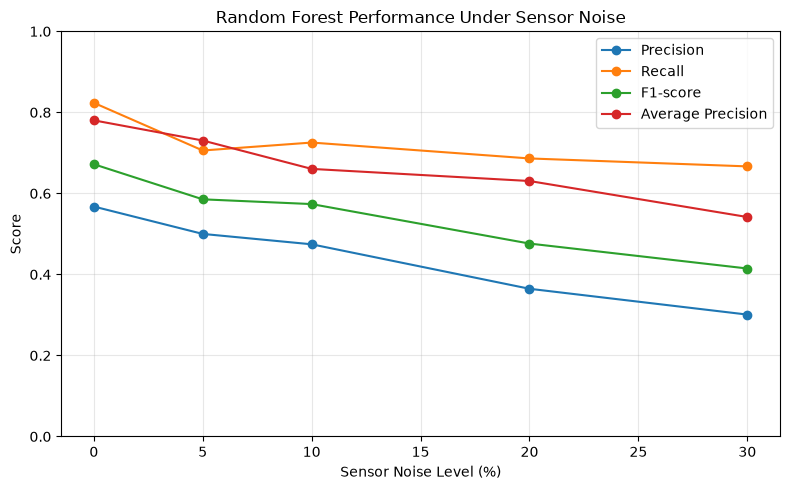

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    noise_results_df["Noise level"] * 100,
    noise_results_df["Precision"],
    marker="o",
    label="Precision"
)

ax.plot(
    noise_results_df["Noise level"] * 100,
    noise_results_df["Recall"],
    marker="o",
    label="Recall"
)

ax.plot(
    noise_results_df["Noise level"] * 100,
    noise_results_df["F1-score"],
    marker="o",
    label="F1-score"
)

ax.plot(
    noise_results_df["Noise level"] * 100,
    noise_results_df["Average precision"],
    marker="o",
    label="Average Precision"
)

ax.set_xlabel("Sensor Noise Level (%)")
ax.set_ylabel("Score")
ax.set_title(
    "Random Forest Performance Under Sensor Noise"
)

ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    project_root
    / "figures"
    / "sensor_noise_robustness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Sensor-Noise Experiment Findings

The results show that the selected Random Forest becomes progressively less
reliable as sensor measurement noise increases.

Under clean conditions, the model achieved a recall of 82.35%, an F1-score
of 67.20%, and an average precision of 78.03%.

At the highest tested noise level of 30%, recall decreased to 66.67%, the
F1-score decreased to 41.46%, and average precision decreased to 54.17%.

Precision showed a particularly large reduction, decreasing from 56.76% on
clean data to 30.09% at 30% sensor noise. This indicates that increasing
measurement corruption causes the model to generate substantially more false
failure warnings.

Although recall does not decrease monotonically at every individual noise
level, the overall trend across the experiment is downward. Small local
variations are expected because the simulated measurement errors are random.

The results demonstrate that the clean-trained Random Forest is sensitive to
sensor measurement corruption. This suggests that sensor quality and
measurement reliability are important considerations when deploying
machine-learning-based predictive-maintenance systems.

In [31]:
noise_results_path = (
    project_root
    / "results"
    / "sensor_noise_results.csv"
)

noise_results_df.to_csv(
    noise_results_path,
    index=False
)

print("Sensor-noise results saved to:")
print(noise_results_path)

Sensor-noise results saved to:
c:\Users\aacaa\Documents\reliable-machine-failure-prediction\results\sensor_noise_results.csv


## 7. Experiment 2 - Missing Sensor Measurements

Industrial sensor systems may occasionally produce missing measurements.

A sensor may temporarily fail, lose communication, or return an invalid value.
For example, a torque, temperature, or rotational-speed measurement may be
unavailable even though the machine is still operating.

In this experiment, controlled percentages of numerical sensor measurements
will be removed from the test set.

The same trained Random Forest model and the same decision threshold of 0.20
will be kept fixed.

The purpose of this experiment is to investigate how prediction performance
changes when some sensor information is unavailable.

In [32]:
def add_missing_sensor_values(
    X_data,
    missing_level,
    numeric_features,
    random_state=RANDOM_STATE
):
    missing_data = X_data.copy()

    rng = np.random.default_rng(random_state)

    random_values = rng.random(
        size=(
            len(X_data),
            len(numeric_features)
        )
    )

    missing_mask = (
        random_values < missing_level
    )

    missing_data.loc[
        :,
        numeric_features
    ] = missing_data[
        numeric_features
    ].mask(missing_mask)

    return missing_data


print("Missing-sensor function created successfully.")

Missing-sensor function created successfully.
